In [6]:
import pandas as pd

data = {
    "score": [5, 65, 70, 72, 95, 78, 80, 0, 82, 85, 88, 75, 135, 150]
}

df = pd.DataFrame(data)

print(df)

    score
0       5
1      65
2      70
3      72
4      95
5      78
6      80
7       0
8      82
9      85
10     88
11     75
12    135
13    150


In [7]:
# 1사분위수 / 3사분위수
Q1 = df["score"].quantile(0.25)
Q3 = df["score"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

# IQR 계산
IQR = Q3 - Q1
print("IQR:", IQR)

# 하한/상한 계산 -
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("하한:", lower)
print("상한:", upper)

Q1: 70.5
Q3: 87.25
IQR: 16.75
하한: 45.375
상한: 112.375


In [8]:
# 이상치 판별
print(df[(df["score"] < lower) | (df["score"] > upper)])

    score
0       5
7       0
12    135
13    150


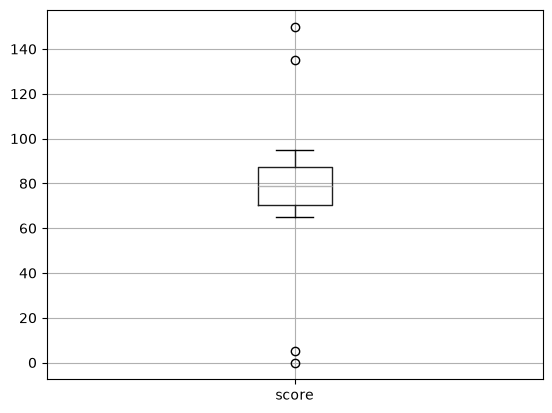

In [9]:
# boxplot으로 탐색하여 확인할 수 도 있다
import matplotlib.pyplot as plt
df.boxplot()
plt.show()

In [11]:
# Scikit-learn으로 Z-score 계산
from scipy.stats import zscore

# 데이터가 작거나 값의 분포에 따라 값이 큰 경우에도 Z-score가 3보다 작게 나올 수도 있다. 
# 예제에서는 데이터 값을 조금 더 극단적으로 만들어 Z-score > 3을 명확하게 보여주는 것이 좋다.

data = {
    "시험점수": [
        65, 70, 72, 75, 78,
        80, 82, 85, 88, 95, 200
    ]
}

df = pd.DataFrame(data)

df["z_score"] = zscore(df["시험점수"])

print(df)

print("이상치:")

outlier = df[abs(df["z_score"]) > 3]
print(outlier)

    시험점수   z_score
0     65 -0.699866
1     70 -0.559893
2     72 -0.503903
3     75 -0.419919
4     78 -0.335936
5     80 -0.279946
6     82 -0.223957
7     85 -0.139973
8     88 -0.055989
9     95  0.139973
10   200  3.079409
이상치:
    시험점수   z_score
10   200  3.079409
